In [1]:
from IPython.core.interactiveshell import InteractiveShell
import time

old_run_cell = InteractiveShell.run_cell

def timing_run_cell(self, raw_cell, *args, **kwargs):
    t0 = time.time()
    result = old_run_cell(self, raw_cell, *args, **kwargs)
    t1 = time.time()
    print(f"Execution time: {t1 - t0:.4f} seconds")
    return result

InteractiveShell.run_cell = timing_run_cell

# Import packages

In [2]:
import scipy.interpolate as spl
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
import sys
from functools import partial
import warnings
import os
import itertools
import pandas as pd
from decimal import Decimal, getcontext
import scipy.optimize as optimize
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation, PillowWriter
import scipy.integrate as spint
from scipy.integrate import solve_ivp
from fractions import Fraction
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor

Execution time: 1.5145 seconds


In [3]:
BARY = pd.read_csv('../data/baryons.csv')
TOTAL = pd.read_csv('../data/galaxies_total_sample.csv')

BARY['Mass(Msun)'] =  pd.to_numeric(BARY['Mass(Msun)'], errors='coerce')
BARY['e_Mass(Msun)'] =  pd.to_numeric(BARY['e_Mass(Msun)'], errors='coerce')
BARY['j'] =  pd.to_numeric(BARY['j'], errors='coerce')
BARY['e_j'] =  pd.to_numeric(BARY['e_j'], errors='coerce')
BARY['fgas'] =  pd.to_numeric(BARY['fgas'], errors='coerce')
BARY['e_fgas'] =  pd.to_numeric(BARY['e_fgas'], errors='coerce')

TOTAL['Mstar'] =  pd.to_numeric(TOTAL['Mstar'], errors='coerce')
TOTAL['e_Mstar'] =  pd.to_numeric(TOTAL['e_Mstar'], errors='coerce')
TOTAL['Mgas'] =  pd.to_numeric(TOTAL['Mgas'], errors='coerce')
TOTAL['e_Mgas'] =  pd.to_numeric(TOTAL['e_Mgas'], errors='coerce')
TOTAL['jstar'] =  pd.to_numeric(TOTAL['jstar'], errors='coerce')
TOTAL['e_jstar'] =  pd.to_numeric(TOTAL['e_jstar'], errors='coerce')
TOTAL['jgas'] =  pd.to_numeric(TOTAL['jgas'], errors='coerce')
TOTAL['e_jgas'] =  pd.to_numeric(TOTAL['e_jgas'], errors='coerce')

obs_Mbar = np.log10(BARY['Mass(Msun)'])
obs_Mbar_errors = BARY['e_Mass(Msun)']/BARY['Mass(Msun)']
obs_Mgas = np.log10(TOTAL['Mgas'])
obs_Mgas_errors = TOTAL['e_Mgas']/TOTAL['Mgas']
obs_Mstar = np.log10(TOTAL['Mstar'])
obs_Mstar_errors = TOTAL['e_Mstar']/TOTAL['Mstar']
obs_jbar = np.log10(BARY['j'])
obs_jbar_errors = BARY['e_j']/BARY['j']
obs_jgas = np.log10(TOTAL['jgas'])
obs_jgas_errors = TOTAL['e_jgas']/TOTAL['jgas']
obs_jstar = np.log10(TOTAL['jstar'])
obs_jstar_errors = TOTAL['e_jstar']/TOTAL['jstar']
obs_fgas = np.log10(BARY['fgas'])
obs_fgas_errors = BARY['e_fgas']/BARY['fgas']
obs_fgas_but_for_stars_and_gas = TOTAL['Mgas']/(TOTAL['Mgas'] + TOTAL['Mstar'])
obs_fgas_but_for_stars_and_gas_errors = np.sqrt( (TOTAL['e_Mgas']/(TOTAL['Mgas'] + TOTAL['Mstar']))**2 + (TOTAL['Mgas']*TOTAL['e_Mstar']/((TOTAL['Mgas'] + TOTAL['Mstar'])**2))**2 )

pavel_dir = '../data/compilation_AM_others/'

pavel_data = {}

for filename in os.listdir(pavel_dir):
    if filename.endswith('.csv'):
        filepath = os.path.join(pavel_dir, filename)
        
        df = pd.read_csv(filepath)
        
        df_name = os.path.splitext(filename)[0]
        #add to superthin: 9.04,2.95,9.85,0.55,9.912537485,2.088484546,0.8658895825
        pavel_data[df_name] = df

HIX_logMstar = np.array([10.5, 10.7, 10.5, 10.5, 10.3, 10.2,  9.8, 10.1, 10.1, 10.1, 10.6, 10.5])
HIX_logMHI = np.log10(1.4 * 10**np.array([10.6, 10.7, 10.5, 10.5, 10.4, 10.3,  9.9, 10.3, 10.4, 10.3, 10.9, 10.5]))
HIX_logMbar = np.log10(10**HIX_logMstar + 10**HIX_logMHI)
HIX_fgas = (10**HIX_logMHI)/(10**HIX_logMbar)
HIX_jbar = np.array([4125.6, 3523.8, 5453.1, 4092.4, 3522.7, 3749.8, 1993. , 3196.7, 3388.2, 6377.8, 9764. , 4117.7])

Execution time: 0.0253 seconds


In [4]:
M_times1 = np.arange(0,12.2,0.1)
log_M_bar_array = np.linspace(8,11.5,50)
dt = 0.1
N = 1.4
A = 0.1625
Rf = 0.3

Execution time: 0.0006 seconds


In [ ]:
def RungeKutta(x, y, dx, dydx):
    # Calculate slopes
    k1 = dx * dydx(x, y)
    k2 = dx * dydx(x + dx / 2., y + k1 / 2.)
    k3 = dx * dydx(x + dx / 2., y + k2 / 2.)
    k4 = dx * dydx(x + dx, y + k3)
    
    # Calculate new x and y
    y_new = y + (1. / 6.) * (k1 + 2 * k2 + 2 * k3 + k4)
    x_new = x + dx
    
    return x_new, y_new

def Sigma_definer(r, r_acc, t_acc, C):
    """
    Defines the gas surface density 2D array M_sigma(r, t).

    r      : 1D radius array (pc)
    r_acc  : scalar accretion scale length (pc)
    t_acc  : scalar accretion timescale (Gyr)
    C      : normalization constant to reach desired M_bar at t0
    """
    n_r = len(r)
    n_t = len(M_times1)
    M_sigma = np.zeros((n_r, n_t))

    # assume M_times1 is monotonically increasing with constant spacing dt
    dt_local = M_times1[1] - M_times1[0]
    t_end = M_times1[-1]

    for i, r_value in enumerate(r):
        def dydx(t, S):
            # accretion term - KS consumption term
            acc = (C / (2.0 * np.pi * (r_acc**2))) * np.exp(-t / t_acc) * np.exp(-r_value / r_acc)
            sfr = SFL(S)
            return acc - sfr

        # initial conditions
        t = 0.0
        S = 0.0
        S_row = np.zeros(n_t)
        S_row[0] = S

        # integrate forward in time following M_times1 grid
        for j in range(1, n_t):
            t, S = RungeKutta(t, S, dt_local, dydx)
            S_row[j] = S

        M_sigma[i, :] = S_row

    return M_sigma


def SFL(sigma, sfl_type='old_ksl'):
    Rf = 0.3
    sigma_arr = np.asarray(sigma, dtype=float)

    # Enforce physical domain: negative gas is set 0
    sigma_pos = np.where(sigma_arr > 0.0, sigma_arr, 0.0)

    if sfl_type == "old_ksl":
        N = 1.4
        A = 0.1625
        SFL_val = (1 - Rf) * A * (sigma_pos**N)

    elif sfl_type == "new_ksl":
        A_ksl = 5.18e-4
        N_ksl = 3.83
        SFL_val = (1 - Rf) * A_ksl * (sigma_pos**N_ksl)

    elif sfl_type == "cutoff_ksl":
        thr = 1.0239163123543726

        with np.errstate(divide='ignore', invalid='ignore'):
            log_sigma = np.where(sigma_pos > 0.0, np.log10(sigma_pos), -np.inf)

        mask = log_sigma < thr

        low_reg  = (1 - Rf) * 5.20e-4 * (sigma_pos**3.83)
        high_reg = (1 - Rf) * 0.1625   * (sigma_pos**1.4)

        SFL_val = np.where(mask, low_reg, high_reg)

    else:
        raise ValueError(f"Unknown sfl_type: {sfl_type}")

    SFL_val = np.where(np.isfinite(SFL_val), SFL_val, 0.0)

    if np.isscalar(sigma):
        return float(SFL_val)
    return SFL_val

def v_btfr_def(M_bar, Ag=47):
    """Returns the value of the velocity from the baryonic Tully-Fisher relation. The default constant
    value Ag is taken from McGaugh (2012)."""
    return (M_bar/Ag)**0.25

def rv_def(M_bar, kpc=True):
    if kpc:
        return -0.005034150233993362*v_btfr_def(M_bar)+2.6658196850679956
    else:
        return -5.034150233993362*v_btfr_def(M_bar)+2665.8196850679956
    
def exp_vrot(r, Mbar, kpc=False):
    rv = rv_def(Mbar, kpc=kpc)
    return v_btfr_def(Mbar)*(1-np.exp(-r/rv))

def analytical_r(x, c, y):
    return x - (c**3 * x) / (c + x)**3 - y

def r_btfr_def(M_bar, j_acc, init=1.0):
    
    rv = rv_def(M_bar, kpc=True)
    yer = j_acc / (2*v_btfr_def(M_bar))
    if hasattr(yer, '__len__'):
        r_acc = []
        for i in range(len(j_acc)):
            r_acc.append(optimize.newton(analytical_r, init, args=(rv[i], yer[i])))
        return np.array(r_acc)
    else:
        return optimize.newton(analytical_r, init, args=(rv, yer))

Execution time: 0.0057 seconds


In [ ]:
def Full_final_definer(Mbar, t_acc, res=120, Rmax=100.1, at_t0=True, SFL_type="old_ksl"):
    """
    Defines the global fraction of gas and baryonic specific angular momentum arrays.
    This function is self-contained; together with the Sigma_definer function, and the functions defining 
    the accretion radius and angular momentum, as well as the baryonic mass and rotational velocity, it 
    alone should give the arrays for the final FINAL graph.
    
    --------------
    Inputs:
        - Mbar (float)           --> Baryonic mass value for which you want to evaluate global gas fraction and 
                                     (specific) angular momentum.
        - t_acc (float)          --> Accretion timescale value. This function now works 
                                     for any number of values within the array!
        - res (float)            --> (optional) Resolution of the radius array; gives the values of the radii at
                                     which values are evaluated. Default is 120 pc.
        - Rmax (float)           --> (optional) Maximum radius to evaluate. Default is 100.1 kpc. Together with
                                     res these defaults were chosen as to optimize run time and convergence of 
                                     specific angular momentum. 
        - at_t0 (bool)           --> (optional) Specifes whether to return just the values today (True), or the 
                                     entire evolution (False). Default is True.
    
    Returns:
        - f_gas_array (np.array) --> Array containing, depending on at_t0, either the values of the global
                                     gas fraction today (t = 12Gyr), or in the entire evolution.
        - j_bar_array (np.array) --> Array containing, depending on at_t0, either the values of the specific
                                     angular momentum today (t = 12Gyr), or in the entire evolution.
    
    """
    
    r = np.arange(0,1000*Rmax,res)
    dr = res
    #Mbar_full = np.full(M_times1.shape, Mbar)
    j_max = (Mbar**0.73)*10**(-4.25)
    j_min = j_max/10
    j_acc_array = np.linspace(j_min, j_max, 10)
    
    r_acc_array = np.zeros(len(j_acc_array))
    for i in range(len(j_acc_array)):
        r_acc_array[i] = 1000*r_btfr_def(Mbar, j_acc_array[i])
    C_c = Mbar/(t_acc*(1-np.exp(-12/t_acc)))
    
    SD_gas = np.array([Sigma_definer(r, r_acc, t_acc, C_c) for r_acc in r_acc_array])
    SD_sfr = np.array([SFL(SD_gas[i], sfl_type=SFL_type) for i in range(len(SD_gas))])
    
    r = r.reshape(len(r),1)
    
    M_gas = np.array([2*np.pi*spint.simpson(r*SD_gas[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_sfr = np.array([2*np.pi*spint.simpson(r*SD_sfr[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_star = np.array([dt*np.cumsum(M_sfr[i]) for i in range(len(SD_gas))])
    M_bar = np.array([np.array([np.sum(x) for x in zip(M_star[i], M_gas[i])]) for i in range(len(SD_gas))])
    f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])

    #Mbar_allsame = np.full(len(M_bar[0]), M_bar[0][-1])
    #v_rot = v_btfr_def(Mbar_allsame[0])
    
    nominator_gas = np.array([2*np.pi*spint.simpson(r**2*SD_gas[i]*exp_vrot(r, Mbar), dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_sfr = np.array([2*np.pi*spint.simpson(r**2*SD_sfr[i]*exp_vrot(r, Mbar), dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_star = np.array([dt*np.cumsum(nominator_sfr[i]) for i in range(len(SD_gas))])
    nominator_bar = np.array([np.array([np.sum(x) for x in zip(nominator_star[i], nominator_gas[i])]) for i in range(len(SD_gas))])
    j_bar = np.array([np.divide(nominator_bar[i], M_bar[i]) for i in range(len(SD_gas))])
    j_gas = np.array([np.divide(nominator_gas[i], M_gas[i]) for i in range(len(SD_gas))])
    j_star = np.array([np.divide(nominator_star[i], M_star[i]) for i in range(len(SD_gas))])
    
    M_star_t0 = M_star[:,-1]
    M_gas_t0  = M_gas[:,-1]
    
    if (at_t0==True):
        f_gas_array = f_gas_global[:,-1]
        j_bar_array = j_bar[:,-1]/1000
        j_gas_array = j_gas[:,-1]/1000
        j_star_array = j_star[:,-1]/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
    else:
        f_gas_array = f_gas_global
        j_bar_array = j_bar/1000
        j_gas_array = j_gas/1000
        j_star_array = j_star/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star, M_gas

def process_mbar(M, t_acc, *args):
    """
    Implements multiprocessing
    """
    return Full_final_definer(10**M, t_acc, *args)

def modelled_j_bar2(f_gas_array, j_bar_array, f_gas_value, kind=1):
    """
    The function takes as input the arrays for f_gas and j_bar (possibly already interpolated), 
    together with a wanted value of f_gas for which to slice out the 1D array. 
    
    ------------
    Inputs:
    - f_gas_array = interpolated 2D array of f_gas
    - j_bar_array = interpolated 2D array of j_bar
    - f_gas_value = value of f_gas for which to slice the f_gas/j_bar arrays
    - kind = Inerpolation type (default is 1 - linear)
    
    The function does the following
    - Creates a list 'index_array', which has the indexes of constant f_gas_value chosen as elements.
    - Then, it iteratively takes from the j_bar_array the values corresponding to the indexes from index_array
    - Finally it interpolates the indexed j_bar_array through the M_bar_array, to get a plottable linear function.
    
    Returns:
    - indexed_M_array_lin = A simple linspace with the initial and final values of the original log_M_bar_array
    """
    indexed_j_array = []
    index_array = []
    true_list = []
    
    for i in range(len(log_M_bar_array)):
        if f_gas_value>np.min(f_gas_array[i]) and f_gas_value<np.max(f_gas_array[i]):
            index_array.append(np.argwhere(f_gas_array[i] == min(f_gas_array[i], key=lambda x:abs(x-f_gas_value))))
            true_list.append(1)
        else:
            index_array.append(0)
            true_list.append(0)
    
    j = 0
    while (j<50):
        if (true_list[j]==1):
            indexed_j_array.append(j_bar_array[j][index_array[j]])
        j += 1
    
    if len(indexed_j_array)>kind:
        index = np.argwhere(np.array(true_list) == 1)
        indexed_M_array = log_M_bar_array[index]
        indexed_M_array_lin = np.linspace(indexed_M_array[0], indexed_M_array[-1], 1000)
        interpolation = spl.InterpolatedUnivariateSpline(indexed_M_array.reshape(len(indexed_M_array),), indexed_j_array, k=kind)
        interpolated_j_array = interpolation(indexed_M_array_lin).reshape(len(indexed_M_array_lin),)
    else:
        indexed_M_array_lin = []
        interpolated_j_array = []
    
    return indexed_M_array_lin, interpolated_j_array

Execution time: 0.0177 seconds


In [ ]:
t_acc_array = np.array([3., 10., 25.]) # Gyr
n_M = len(log_M_bar_array)
n_tac = len(t_acc_array)

# Arrays: first index = mass, second index = t_acc
f_gas_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_bar_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_gas_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_star_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
Mstar_grid = np.zeros((n_M, n_tac, 10))
Mgas_grid  = np.zeros((n_M, n_tac, 10))

for j_tac, t_acc in enumerate(t_acc_array):
    print(f"Running models for t_acc = {t_acc:.1f} Gyr")

    # process_mbar takes (M, t_acc)
    process_mbar_cutoff_ksl = partial(process_mbar, t_acc=t_acc)

    # parallelize over M for this fixed t_acc
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(process_mbar_cutoff_ksl, log_M_bar_array))

    # unpack results into [:, j_tac, :]
    for i_M, (f_gas_temp, j_bar_temp, j_gas_temp, j_star_temp,
              Ms_temp,   Mg_temp) in enumerate(results):

        f_gas_array_10_50_cutoff_ksl[i_M, j_tac, :] = f_gas_temp
        j_bar_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_bar_temp
        j_gas_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_gas_temp
        j_star_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_star_temp
        Mstar_grid[i_M, j_tac, :] = Ms_temp
        Mgas_grid[i_M, j_tac, :] = Mg_temp

np.save('../data/data_elise_new_rot/final_f_gas_cutoff_ksl.npy', f_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_bar_cutoff_ksl.npy', j_bar_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_gas_cutoff_ksl.npy', j_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_star_cutoff_ksl.npy', j_star_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_Mstar_grid_cutoff_ksl.npy', Mstar_grid)
np.save('../data/data_elise_new_rot/final_Mgas_grid_cutoff_ksl.npy', Mgas_grid)

Running models for t_acc = 3.0 Gyr


Process ForkProcess-125:
Process ForkProcess-106:
Process ForkProcess-111:
Process ForkProcess-107:
Process ForkProcess-110:
Process ForkProcess-102:
Process ForkProcess-109:
Process ForkProcess-113:
Process ForkProcess-126:
Process ForkProcess-124:
Process ForkProcess-112:
Process ForkProcess-51:
Process ForkProcess-122:
Process ForkProcess-101:
Process ForkProcess-100:
Process ForkProcess-123:
Process ForkProcess-116:
Process ForkProcess-98:
Process ForkProcess-117:
Process ForkProcess-118:
Process ForkProcess-120:
Process ForkProcess-88:
Process ForkProcess-108:
Process ForkProcess-60:
Process ForkProcess-66:
Process ForkProcess-119:
Process ForkProcess-68:
Process ForkProcess-89:
Process ForkProcess-103:
Process ForkProcess-99:
Process ForkProcess-69:
Process ForkProcess-104:
Process ForkProcess-56:
Process ForkProcess-97:
Process ForkProcess-70:
Process ForkProcess-63:
Process ForkProcess-95:
Process ForkProcess-81:
Process ForkProcess-76:
Process ForkProcess-90:
Process ForkProce

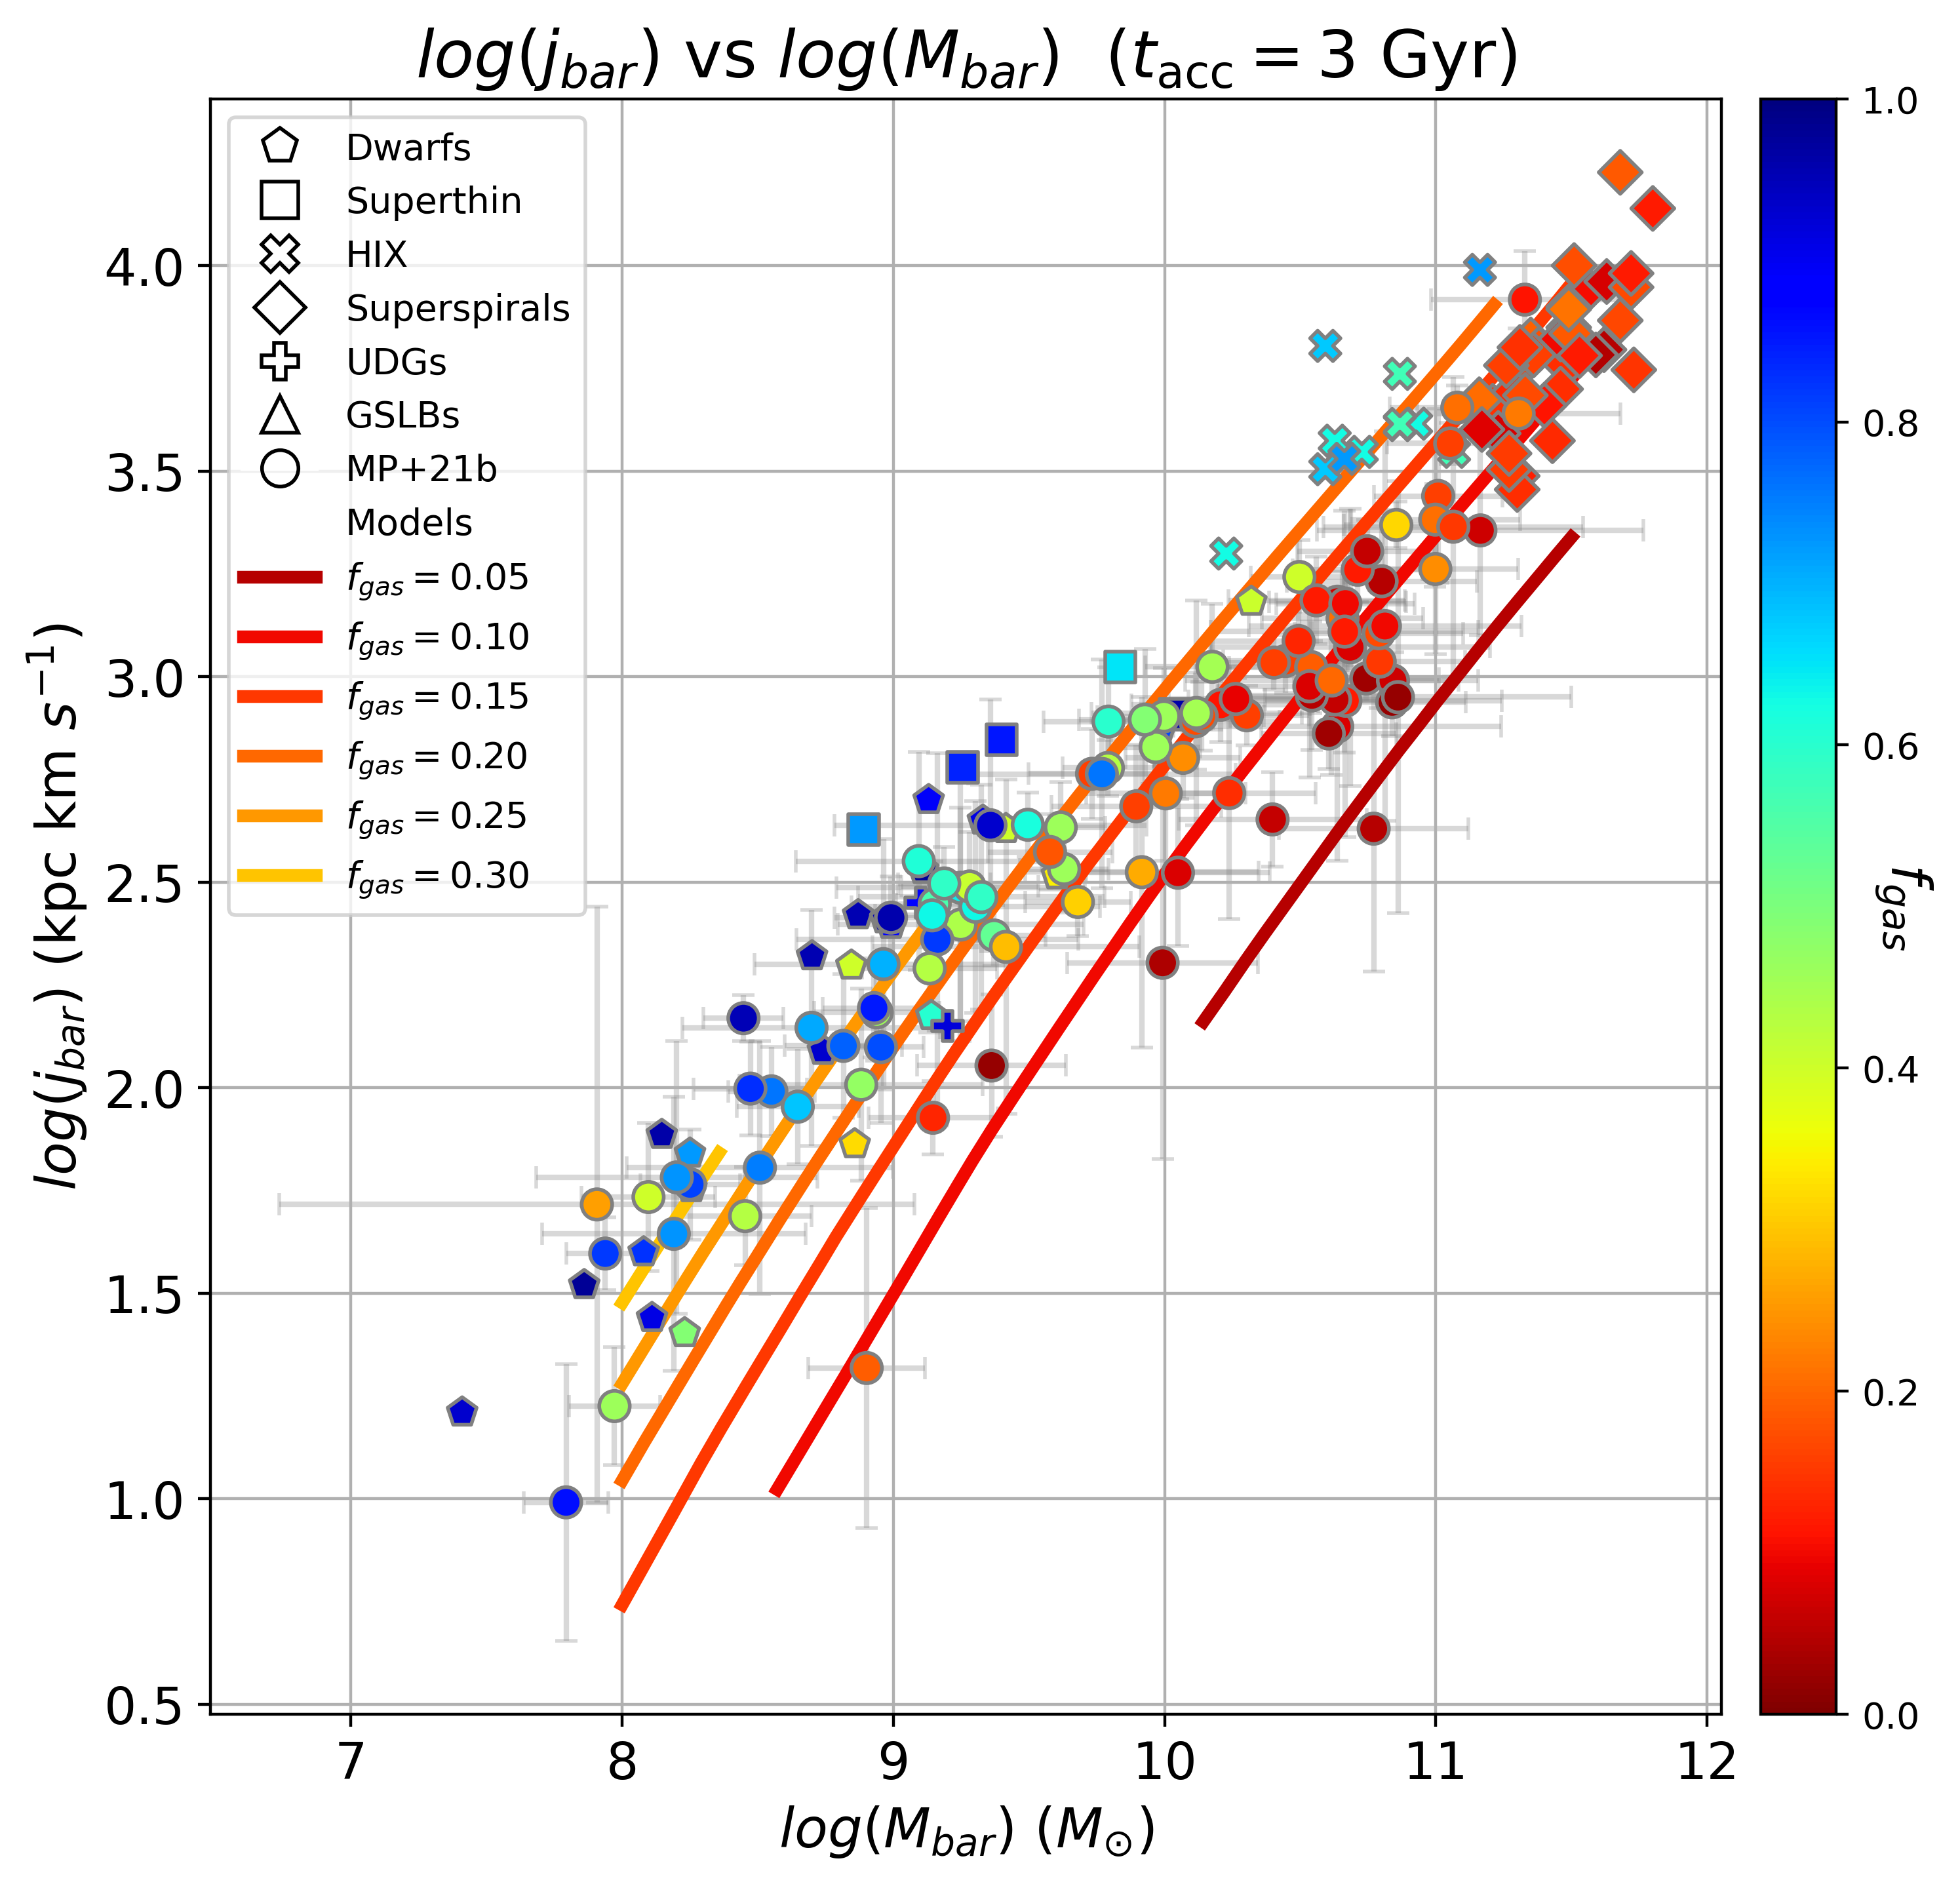

Execution time: 1.2824 seconds


In [ ]:
log_j_bar_array_10_50 = np.log10(j_bar_array_10_50_cutoff_ksl)

cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 0, :].min(),f_gas_array_10_50_cutoff_ksl[i, 0, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 0, :], log_j_bar_array_10_50[i, 0, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GSLBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GSLBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$  ($t_{\mathrm{acc}} = 3$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).png')

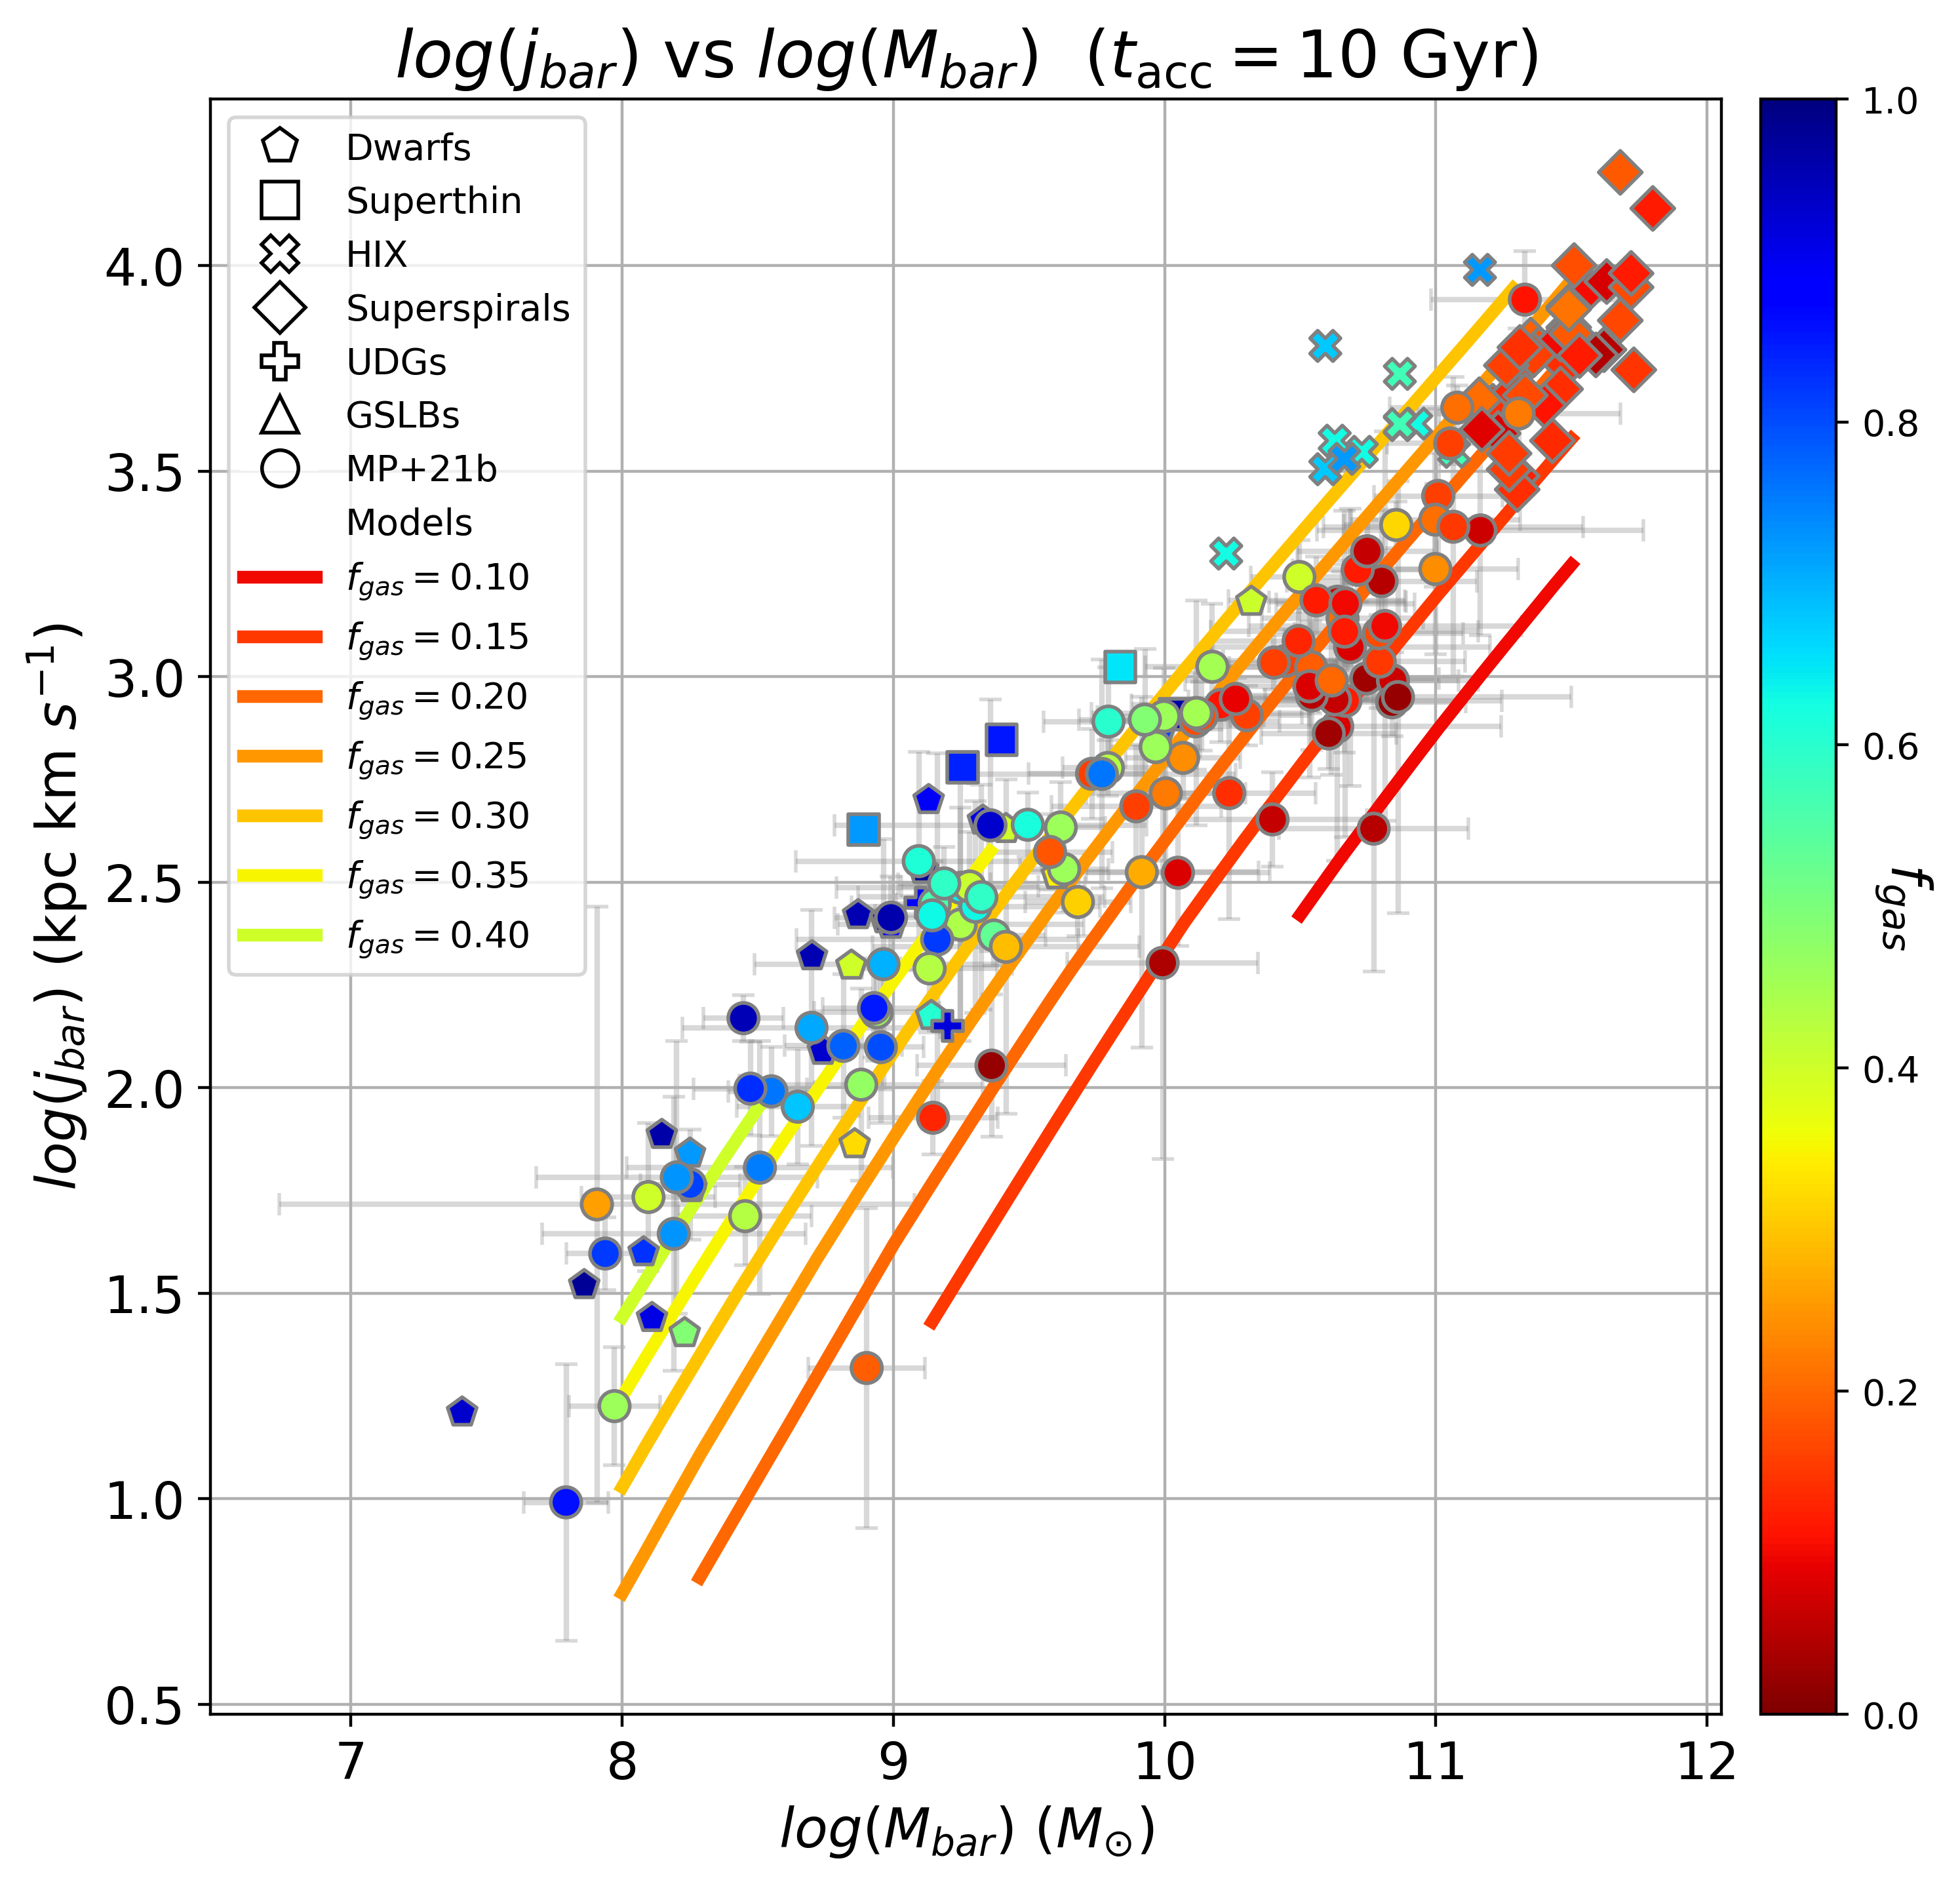

Execution time: 0.8614 seconds


In [ ]:
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 1, :].min(),f_gas_array_10_50_cutoff_ksl[i, 1, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 1, :], log_j_bar_array_10_50[i, 1, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GSLBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GSLBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$  ($t_{\mathrm{acc}} = 10$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).png')

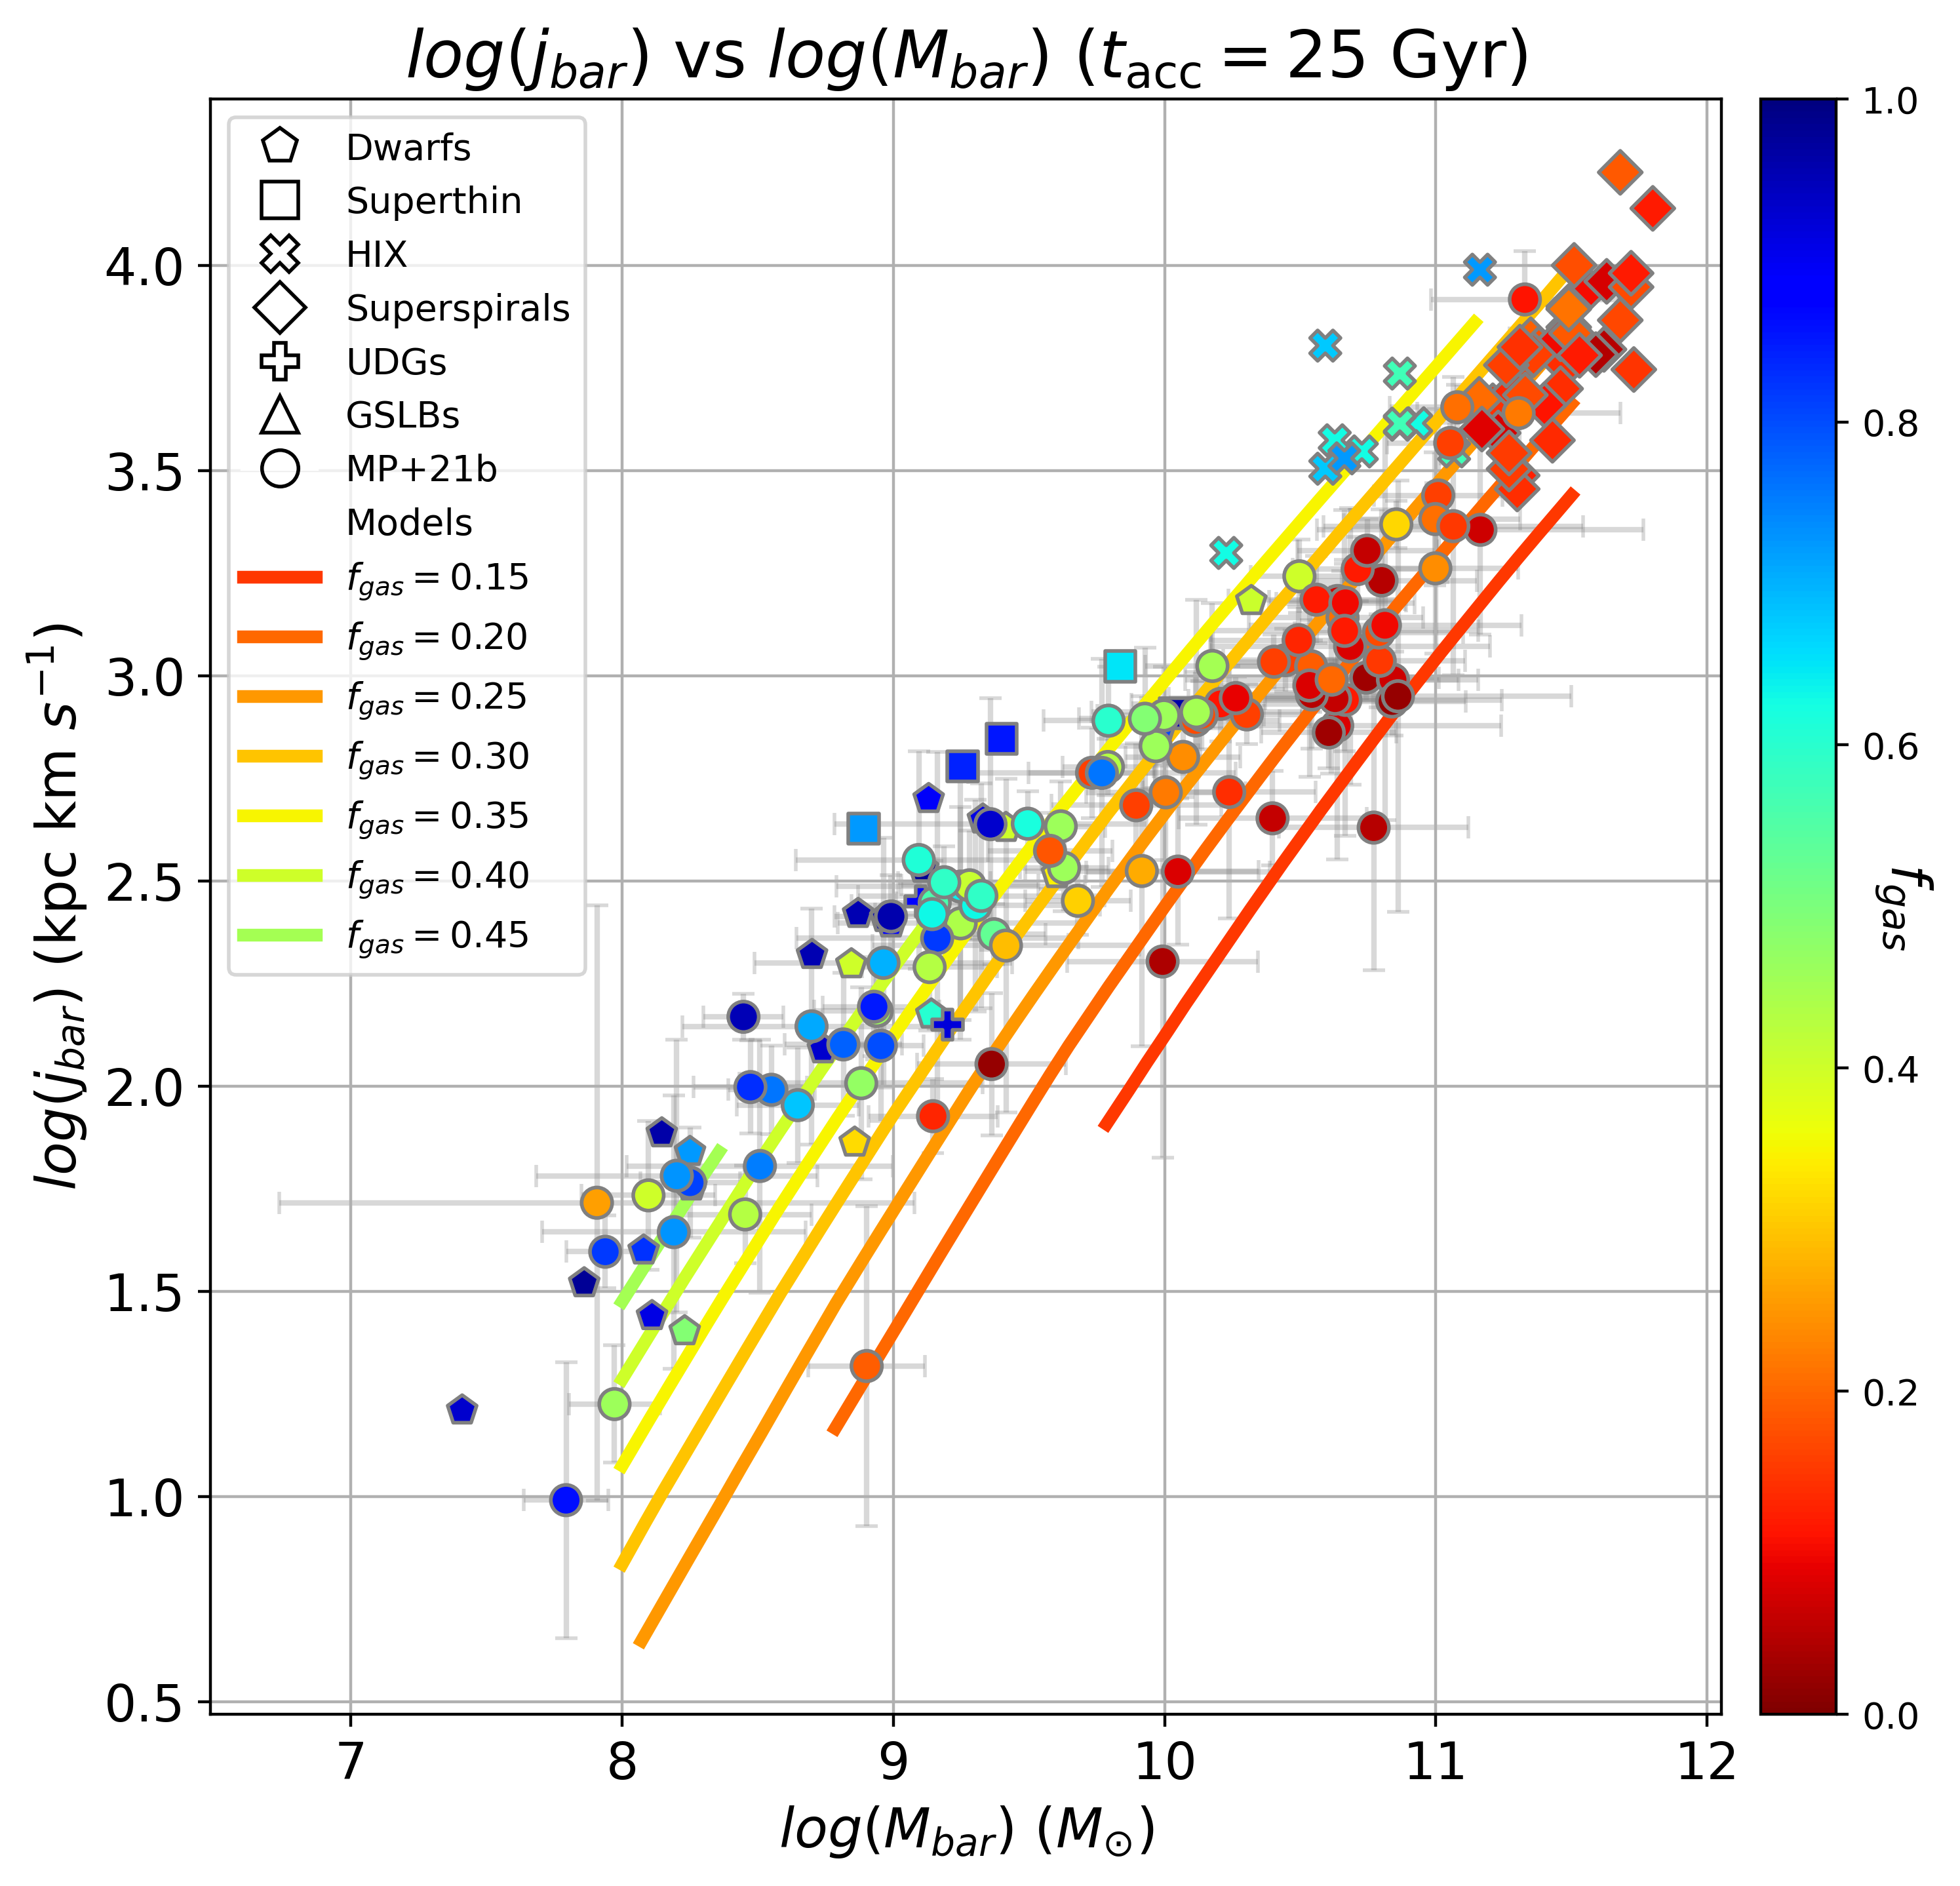

Execution time: 0.8496 seconds


In [ ]:
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 2, :].min(),f_gas_array_10_50_cutoff_ksl[i, 2, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 2, :], log_j_bar_array_10_50[i, 2, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GSLBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GSLBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$ ($t_{\mathrm{acc}} = 25$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).png')